# NinaPro DB5 Exercise A 滑动窗口数据准备

本 Notebook 完成以下任务：

1. 下载 NinaPro DB5 全部 10 名受试者的数据；
2. 只提取并读取 Exercise A；
3. 检查、清洗并可视化 16 通道 sEMG；
4. 按动作重复编号划分训练集和测试集；
5. 使用 200 ms 窗口、100 ms 步长切分数据；
6. 将结果保存为方便 PyTorch 使用的压缩 NPZ 文件。

数据划分严格遵循“先按重复编号划分，再滑动窗口切分”的原则，避免相邻窗口跨集合造成数据泄漏。

## 1. 导入依赖并设置参数

本流程只依赖常见的科学计算库，不要求当前环境已经安装 PyTorch。

In [ ]:
from pathlib import Path
import json
import re
import shutil
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from scipy.io import loadmat
from tqdm.auto import tqdm

# 让图表在不同系统上尽量正确显示中文；若本机缺少中文字体，数值和英文仍可正常显示
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font_scale=0.9)


def find_project_root() -> Path:
    """从当前工作目录向上寻找同时包含 src 和 ninapro_data 的项目根目录。"""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到项目根目录，请从项目根目录或 src 文件夹启动 Notebook。")


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "ninapro_data"
ARCHIVE_DIR = DATA_ROOT / "raw" / "archives"
EXERCISE_DIR = DATA_ROOT / "raw" / "exerciseA"
OUTPUT_DIR = DATA_ROOT / "processed" / "exerciseA" / "slide_window"

for directory in (ARCHIVE_DIR, EXERCISE_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# DB5 Exercise A 的固定配置
SUBJECT_IDS = list(range(1, 11))
SAMPLE_RATE = 200
N_CHANNELS = 16
WINDOW_MS = 200
STRIDE_MS = 100
WINDOW_SIZE = SAMPLE_RATE * WINDOW_MS // 1000   # 40 个采样点
STRIDE_SIZE = SAMPLE_RATE * STRIDE_MS // 1000   # 20 个采样点
TRAIN_REPETITIONS = (1, 3, 4, 6)
TEST_REPETITIONS = (2, 5)

# 官方下载地址优先，Zenodo 作为回退地址
OFFICIAL_BASE_URL = "https://ninapro.hevs.ch/files/DB5_Preproc"
ZENODO_BASE_URL = "https://zenodo.org/records/1000116/files"

GESTURE_NAMES = {
    1: "食指屈曲", 2: "食指伸展",
    3: "中指屈曲", 4: "中指伸展",
    5: "无名指屈曲", 6: "无名指伸展",
    7: "小指屈曲", 8: "小指伸展",
    9: "拇指内收", 10: "拇指外展",
    11: "拇指屈曲", 12: "拇指伸展",
}

print(f"项目目录：{PROJECT_ROOT}")
print(f"原始压缩包目录：{ARCHIVE_DIR}")
print(f"处理结果目录：{OUTPUT_DIR}")
print(f"窗口：{WINDOW_SIZE} 点（{WINDOW_MS} ms），步长：{STRIDE_SIZE} 点（{STRIDE_MS} ms）")

项目目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro
原始压缩包目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\raw\archives
处理结果目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\slide_window
窗口：40 点（200 ms），步长：20 点（100 ms）


## 2. 下载并校验数据集

每名受试者对应一个 ZIP 文件。下载过程具有以下特性：

- 使用数据流和进度条，避免一次将整个文件读入内存；
- 先写入 `.part` 临时文件，成功后再替换正式文件；
- 自动校验 ZIP 完整性；
- 已存在且完整的文件会直接复用；
- 官方地址失败时自动尝试 Zenodo。

In [6]:
def zip_is_valid(path: Path) -> bool:
    """检查文件是否为可正常读取的完整 ZIP。"""
    if not path.is_file() or path.stat().st_size == 0:
        return False
    try:
        with zipfile.ZipFile(path) as archive:
            return archive.testzip() is None
    except (zipfile.BadZipFile, OSError):
        return False


def stream_download(session: requests.Session, url: str, destination: Path) -> None:
    """将一个 URL 流式下载到指定文件，并在下载完成后进行 ZIP 校验。"""
    temporary = destination.with_suffix(destination.suffix + ".part")
    temporary.unlink(missing_ok=True)

    with session.get(url, stream=True, timeout=(20, 180), allow_redirects=True) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))
        with temporary.open("wb") as file_handle, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc=destination.name,
            leave=False,
        ) as progress:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file_handle.write(chunk)
                    progress.update(len(chunk))

    if not zip_is_valid(temporary):
        temporary.unlink(missing_ok=True)
        raise zipfile.BadZipFile(f"下载结果不是完整 ZIP：{url}")

    temporary.replace(destination)


def download_subject_archive(subject_id: int, session: requests.Session) -> Path:
    """下载一名受试者的数据；每个数据源最多尝试两次。"""
    destination = ARCHIVE_DIR / f"s{subject_id}.zip"
    if zip_is_valid(destination):
        print(f"[复用] {destination.name}")
        return destination

    # 如果已有文件损坏，只删除这个明确的数据压缩包后重新下载
    destination.unlink(missing_ok=True)
    sources = [
        f"{OFFICIAL_BASE_URL}/s{subject_id}.zip",
        f"{ZENODO_BASE_URL}/s{subject_id}.zip?download=1",
    ]
    errors = []

    for url in sources:
        for attempt in range(1, 3):
            try:
                print(f"[下载] S{subject_id}，来源：{url.split('/')[2]}，尝试 {attempt}/2")
                stream_download(session, url, destination)
                return destination
            except (requests.RequestException, OSError, zipfile.BadZipFile) as error:
                errors.append(f"{url}（第 {attempt} 次）：{error}")
                destination.with_suffix(destination.suffix + ".part").unlink(missing_ok=True)
                time.sleep(attempt)

    raise RuntimeError("所有下载地址均失败：\n" + "\n".join(errors))


session = requests.Session()
session.headers.update({"User-Agent": "NinaPro-DB5-E1-Notebook/1.0"})

archive_paths = [download_subject_archive(subject_id, session) for subject_id in SUBJECT_IDS]
assert len(archive_paths) == 10 and all(zip_is_valid(path) for path in archive_paths)
print("10 个受试者的压缩包均已准备并通过完整性检查。")

[复用] s1.zip
[复用] s2.zip
[复用] s3.zip
[复用] s4.zip
[复用] s5.zip
[复用] s6.zip
[复用] s7.zip
[复用] s8.zip
[复用] s9.zip
[复用] s10.zip
10 个受试者的压缩包均已准备并通过完整性检查。


## 3. 只提取 Exercise A

每个 ZIP 同时包含多个 Exercise。这里仅查找并提取 `S*_E1_A1.mat`，以减少磁盘占用。

In [7]:
REQUIRED_MAT_VARIABLES = {"emg", "restimulus", "rerepetition"}


def mat_is_readable(path: Path) -> bool:
    """检查 MAT 文件是否能读取到后续必需的三个变量。"""
    if not path.is_file() or path.stat().st_size == 0:
        return False
    try:
        content = loadmat(path, variable_names=sorted(REQUIRED_MAT_VARIABLES))
        return REQUIRED_MAT_VARIABLES.issubset(content)
    except Exception:
        return False


def extract_exercise_a(subject_id: int, archive_path: Path) -> Path:
    """从一名受试者的 ZIP 中提取 Exercise A，兼容 ZIP 内部存在子目录。"""
    expected_name = f"S{subject_id}_E1_A1.mat"
    destination = EXERCISE_DIR / expected_name
    if mat_is_readable(destination):
        print(f"[复用] {destination.name}")
        return destination

    destination.unlink(missing_ok=True)
    temporary = destination.with_suffix(".mat.part")
    temporary.unlink(missing_ok=True)

    with zipfile.ZipFile(archive_path) as archive:
        candidates = [
            member for member in archive.namelist()
            if not member.endswith("/") and Path(member).name.lower() == expected_name.lower()
        ]
        if len(candidates) != 1:
            raise FileNotFoundError(
                f"{archive_path.name} 中应有且仅有一个 {expected_name}，实际找到 {len(candidates)} 个。"
            )
        with archive.open(candidates[0]) as source, temporary.open("wb") as target:
            shutil.copyfileobj(source, target)

    temporary.replace(destination)
    if not mat_is_readable(destination):
        destination.unlink(missing_ok=True)
        raise ValueError(f"提取后的 MAT 文件无法正常读取：{destination}")
    return destination


mat_paths = {
    subject_id: extract_exercise_a(subject_id, archive_paths[subject_id - 1])
    for subject_id in SUBJECT_IDS
}
assert len(mat_paths) == 10 and all(mat_is_readable(path) for path in mat_paths.values())
print("Exercise A 的 10 个 MAT 文件均已准备完成。")

[复用] S1_E1_A1.mat
[复用] S2_E1_A1.mat
[复用] S3_E1_A1.mat
[复用] S4_E1_A1.mat
[复用] S5_E1_A1.mat
[复用] S6_E1_A1.mat
[复用] S7_E1_A1.mat
[复用] S8_E1_A1.mat
[复用] S9_E1_A1.mat
[复用] S10_E1_A1.mat
Exercise A 的 10 个 MAT 文件均已准备完成。


## 4. 读取数据并执行质量检查

使用 `restimulus` 作为修正后的动作标签，使用 `rerepetition` 作为对应的重复编号。本步骤不做滤波、标准化或幅值裁剪，只检查数据结构和无效值。

In [9]:
def load_subject(subject_id: int, path: Path) -> dict:
    """读取一名受试者的数据，统一数据类型并检查数组结构。"""
    content = loadmat(path, variable_names=["emg", "restimulus", "rerepetition"])
    emg = np.asarray(content["emg"], dtype=np.float32)
    labels = np.asarray(content["restimulus"]).reshape(-1).astype(np.int16)
    repetitions = np.asarray(content["rerepetition"]).reshape(-1).astype(np.int8)

    if emg.ndim != 2 or emg.shape[1] != N_CHANNELS:
        raise ValueError(f"S{subject_id} 的 emg 形状应为 [N, 16]，实际为 {emg.shape}。")
    if not (len(emg) == len(labels) == len(repetitions)):
        raise ValueError(f"S{subject_id} 的 emg、restimulus、rerepetition 长度不一致。")
    if not set(np.unique(labels)).issubset(set(range(13))):
        raise ValueError(f"S{subject_id} 出现预期范围 0～12 之外的动作标签。")

    finite_rows = np.isfinite(emg).all(axis=1)
    active_labels = (labels >= 1) & (labels <= 12)
    valid_repetitions = np.isin(repetitions, range(1, 7))
    valid_rows = finite_rows & active_labels & valid_repetitions

    return {
        "subject_id": subject_id,
        "path": path,
        "emg": emg,
        "labels": labels,
        "repetitions": repetitions,
        "finite_rows": finite_rows,
        "valid_rows": valid_rows,
    }


records = [load_subject(subject_id, mat_paths[subject_id]) for subject_id in SUBJECT_IDS]

quality_rows = []
for record in records:
    active = (record["labels"] >= 1) & (record["labels"] <= 12)
    active_valid_repetition = active & np.isin(record["repetitions"], range(1, 7))
    quality_rows.append({
        "受试者": record["subject_id"],
        "总采样点": len(record["emg"]),
        "动作采样点": int(active.sum()),
        "有效动作采样点": int(record["valid_rows"].sum()),
        "含NaN/Inf的行": int((~record["finite_rows"]).sum()),
        "动作区无效重复编号": int((active & ~active_valid_repetition).sum()),
        "动作类别数": int(np.unique(record["labels"][record["valid_rows"]]).size),
        "重复编号数": int(np.unique(record["repetitions"][record["valid_rows"]]).size),
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

assert quality_df["动作类别数"].eq(12).all(), "部分受试者缺少 Exercise A 动作类别。"
assert quality_df["重复编号数"].eq(6).all(), "部分受试者缺少动作重复。"
print("数据结构与标签检查通过。无效数值将在连续区段和窗口生成阶段被排除。")

,受试者,总采样点,动作采样点,有效动作采样点,含NaN/Inf的行,动作区无效重复编号,动作类别数,重复编号数
0,1,130267,49672,49672,0,0,12,6
1,2,148367,61941,61941,0,0,12,6
2,3,131366,48051,48051,0,0,12,6
3,4,151664,59442,59442,0,0,12,6
4,5,148526,49799,49799,0,0,12,6
5,6,151793,63414,63414,0,0,12,6
6,7,151206,54992,54992,0,0,12,6
7,8,147802,52783,52783,0,0,12,6
8,9,148120,52418,52418,0,0,12,6
9,10,149919,61122,61122,0,0,12,6


数据结构与标签检查通过。无效数值将在连续区段和窗口生成阶段被排除。


## 5. 可视化分析

下面依次观察代表性动作波形、动作与重复的数据量、通道幅值分布，以及不同动作在各通道上的 RMS 强度。

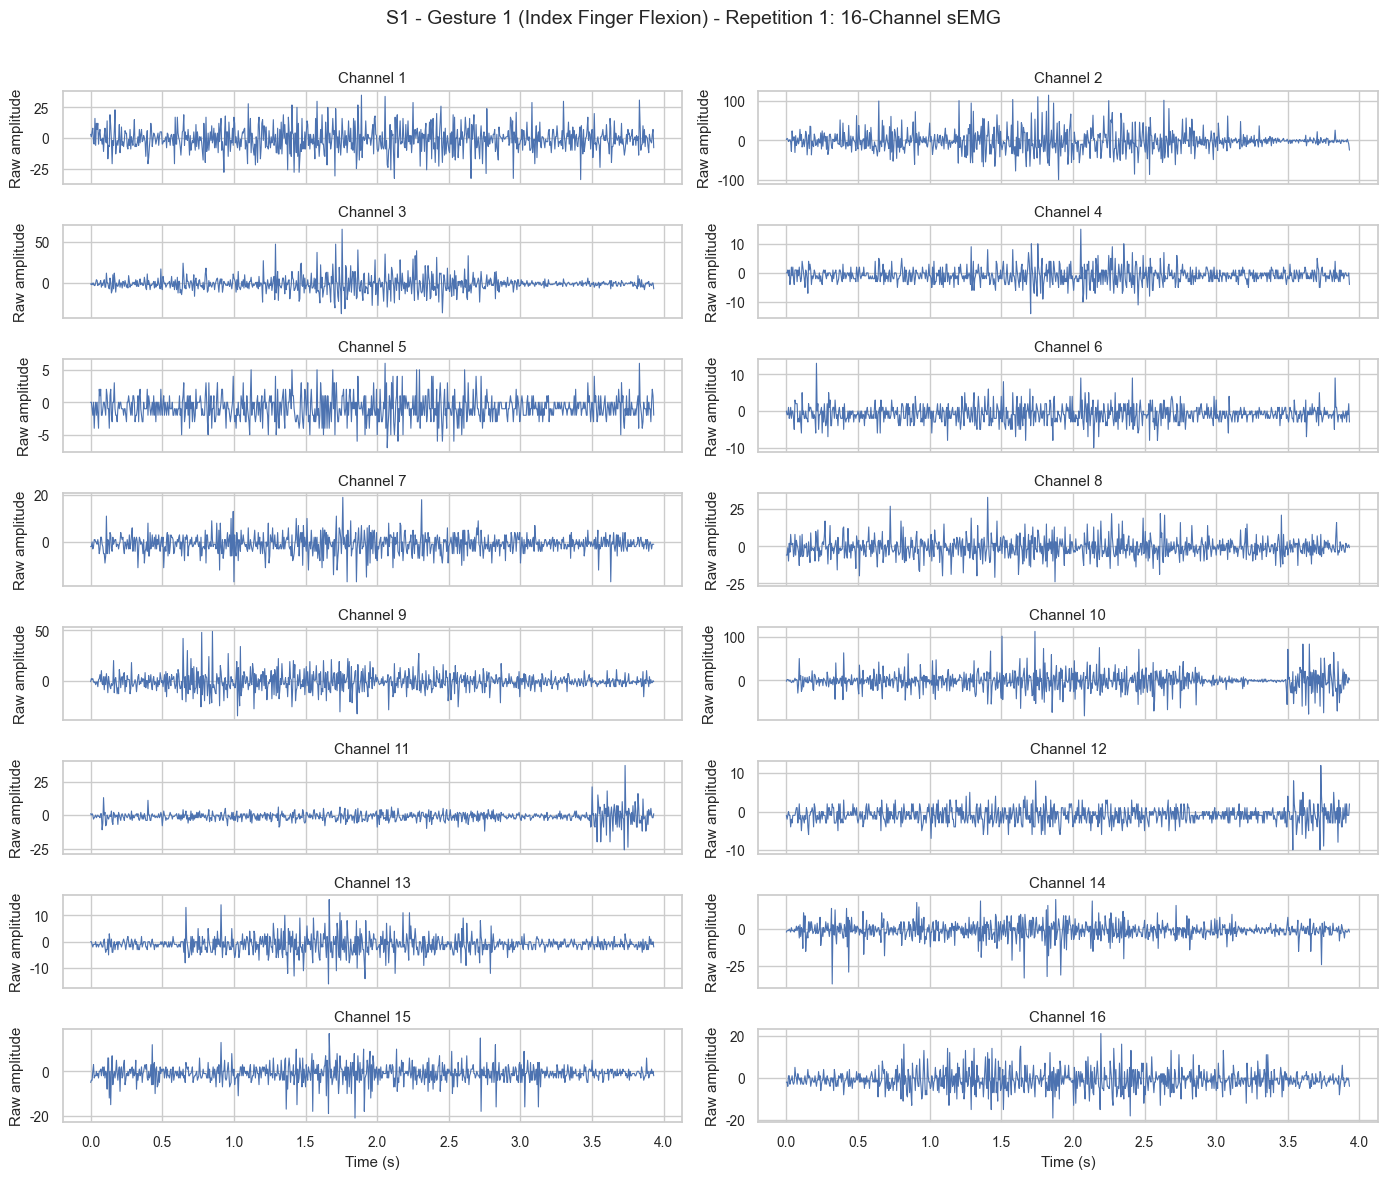

In [10]:
def contiguous_segments(record: dict):
    """按有效性、标签和重复编号生成连续区段，避免跨越静息和动作边界。"""
    labels = record["labels"]
    repetitions = record["repetitions"]
    valid = record["valid_rows"]

    changes = np.ones(len(labels), dtype=bool)
    changes[1:] = (
        (valid[1:] != valid[:-1])
        | (labels[1:] != labels[:-1])
        | (repetitions[1:] != repetitions[:-1])
    )

    starts = np.flatnonzero(changes)
    ends = np.r_[starts[1:], len(labels)]

    for start, end in zip(starts, ends):
        if valid[start]:
            yield (
                int(start),
                int(end),
                int(labels[start]),
                int(repetitions[start]),
            )


# 选择 S1、动作 1、重复 1 中最长的连续区段
example_record = records[0]
example_candidates = [
    segment
    for segment in contiguous_segments(example_record)
    if segment[2] == 1 and segment[3] == 1
]

example_start, example_end, _, _ = max(
    example_candidates,
    key=lambda item: item[1] - item[0],
)

example_emg = example_record["emg"][example_start:example_end]
example_time = np.arange(len(example_emg)) / SAMPLE_RATE

# 绘制 16 通道原始 sEMG 波形，图中文字全部使用英文
fig, axes = plt.subplots(
    8,
    2,
    figsize=(14, 12),
    sharex=True,
)

for channel, axis in enumerate(axes.flat):
    axis.plot(
        example_time,
        example_emg[:, channel],
        linewidth=0.8,
    )
    axis.set_title(f"Channel {channel + 1}")
    axis.set_ylabel("Raw amplitude")

for axis in axes[-1]:
    axis.set_xlabel("Time (s)")

fig.suptitle(
    "S1 - Gesture 1 (Index Finger Flexion) - Repetition 1: "
    "16-Channel sEMG",
    fontsize=14,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [11]:
# 先设置绘图主题，再指定中文字体
sns.set_theme(style="whitegrid")

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

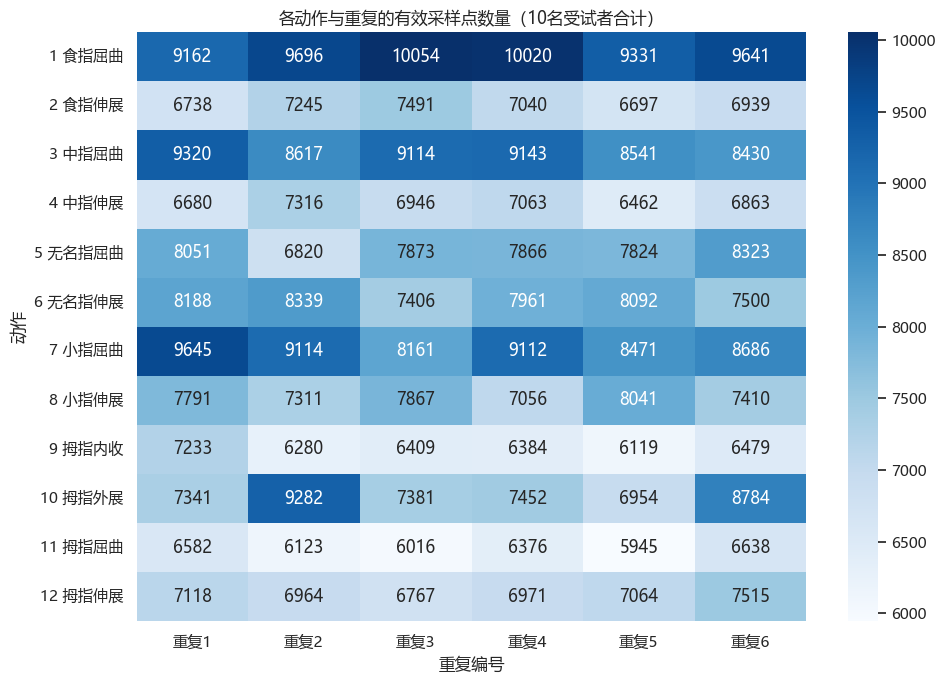

In [12]:
# 汇总所有受试者在每个动作、每个重复中的有效采样点数量
count_matrix = np.zeros((12, 6), dtype=np.int64)
for record in records:
    for raw_label in range(1, 13):
        for repetition in range(1, 7):
            mask = (
                record["valid_rows"]
                & (record["labels"] == raw_label)
                & (record["repetitions"] == repetition)
            )
            count_matrix[raw_label - 1, repetition - 1] += int(mask.sum())

plt.figure(figsize=(10, 7))
sns.heatmap(
    count_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"重复{i}" for i in range(1, 7)],
    yticklabels=[f"{i} {GESTURE_NAMES[i]}" for i in range(1, 13)],
)
plt.title("各动作与重复的有效采样点数量（10名受试者合计）")
plt.xlabel("重复编号")
plt.ylabel("动作")
plt.tight_layout()
plt.show()

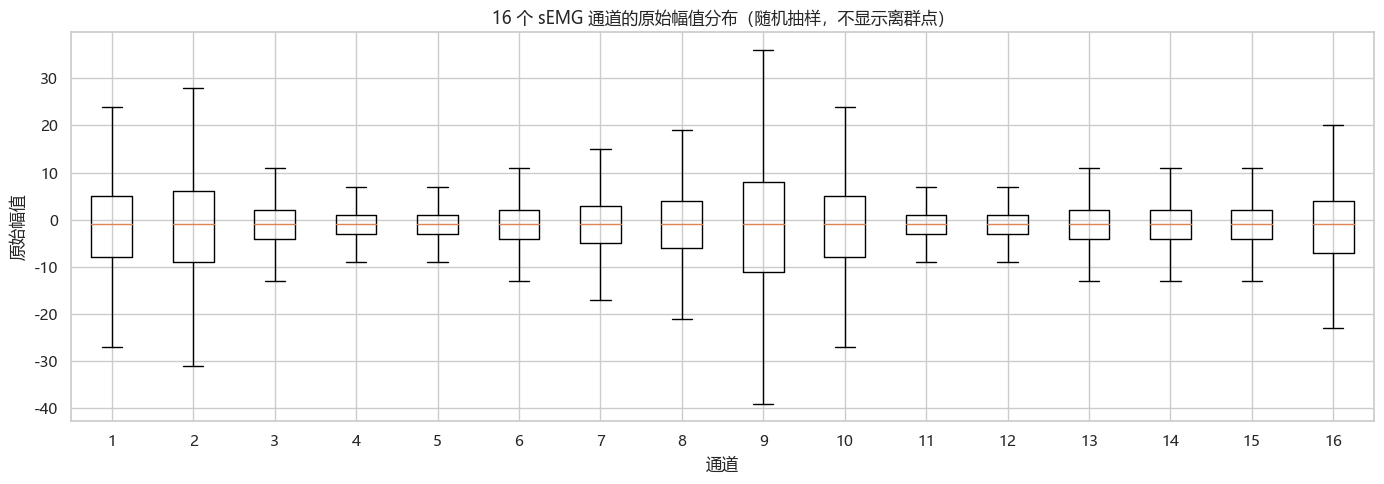

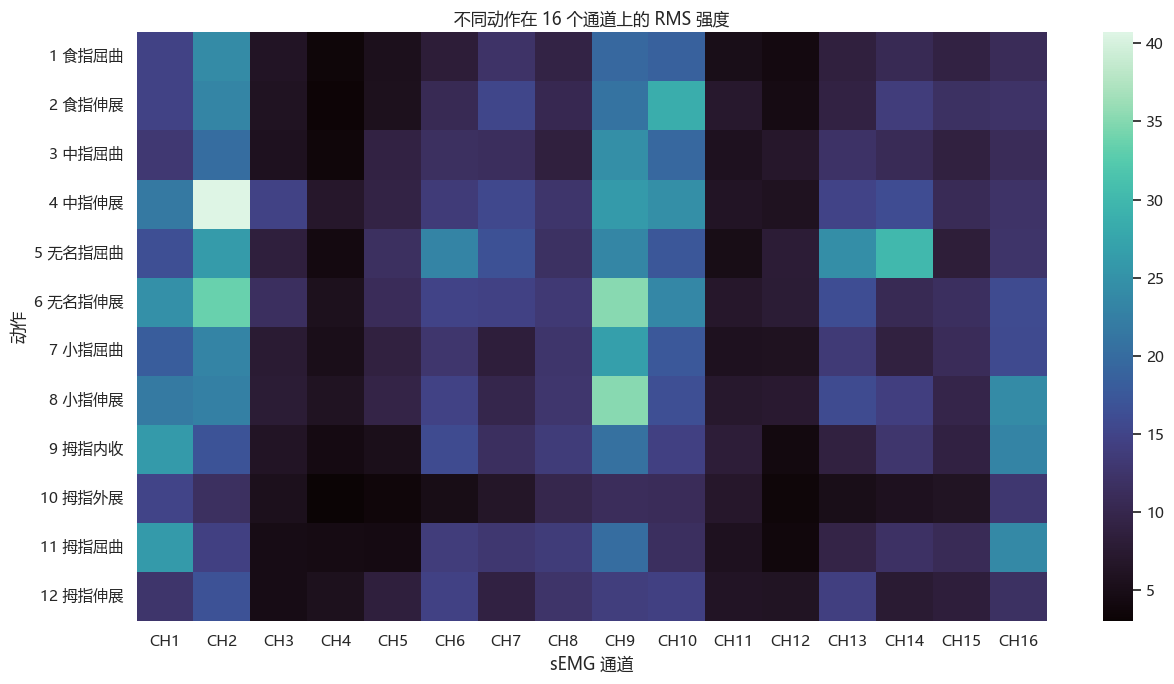

In [13]:
# 为避免箱线图过密，每个受试者最多随机抽取 3000 个有效动作采样点
random_generator = np.random.default_rng(42)
amplitude_samples = []
for record in records:
    valid_indices = np.flatnonzero(record["valid_rows"])
    sample_size = min(3000, len(valid_indices))
    selected = random_generator.choice(valid_indices, size=sample_size, replace=False)
    amplitude_samples.append(record["emg"][selected])

amplitude_samples = np.concatenate(amplitude_samples, axis=0)
plt.figure(figsize=(14, 5))
plt.boxplot(
    [amplitude_samples[:, channel] for channel in range(N_CHANNELS)],
    showfliers=False,
)
plt.title("16 个 sEMG 通道的原始幅值分布（随机抽样，不显示离群点）")
plt.xlabel("通道")
plt.ylabel("原始幅值")
plt.xticks(range(1, 17))
plt.tight_layout()
plt.show()

# 计算每个动作在各通道上的 RMS，观察动作对应的肌肉激活模式
rms_matrix = np.zeros((12, N_CHANNELS), dtype=np.float64)
for raw_label in range(1, 13):
    label_data = np.concatenate([
        record["emg"][record["valid_rows"] & (record["labels"] == raw_label)]
        for record in records
    ], axis=0)
    rms_matrix[raw_label - 1] = np.sqrt(np.mean(np.square(label_data.astype(np.float64)), axis=0))

plt.figure(figsize=(13, 7))
sns.heatmap(
    rms_matrix,
    cmap="mako",
    xticklabels=[f"CH{i}" for i in range(1, 17)],
    yticklabels=[f"{i} {GESTURE_NAMES[i]}" for i in range(1, 13)],
)
plt.title("不同动作在 16 个通道上的 RMS 强度")
plt.xlabel("sEMG 通道")
plt.ylabel("动作")
plt.tight_layout()
plt.show()

## 6. 先按重复编号划分，再生成滑动窗口

- 训练集：重复 1、3、4、6；
- 测试集：重复 2、5；
- 每个窗口形状为 `[16, 40]`；
- 原始标签 `1～12` 映射为 PyTorch 交叉熵常用的 `0～11`。

窗口只在同一连续动作区段内部生成，因此不会跨越静息、动作边界、重复边界或无效采样点。

In [14]:
def create_window_datasets(records):
    """按重复编号选择集合，并在连续动作区段内生成固定长度窗口。"""
    buffers = {
        "train": {"X": [], "y": [], "subject": [], "repetition": [], "start_sample": []},
        "test": {"X": [], "y": [], "subject": [], "repetition": [], "start_sample": []},
    }
    statistics = {
        "valid_segments": 0,
        "short_segments_skipped": 0,
        "samples_outside_selected_repetitions": 0,
    }

    for record in records:
        for segment_start, segment_end, raw_label, repetition in contiguous_segments(record):
            if repetition in TRAIN_REPETITIONS:
                split = "train"
            elif repetition in TEST_REPETITIONS:
                split = "test"
            else:
                statistics["samples_outside_selected_repetitions"] += segment_end - segment_start
                continue

            statistics["valid_segments"] += 1
            if segment_end - segment_start < WINDOW_SIZE:
                statistics["short_segments_skipped"] += 1
                continue

            for start in range(segment_start, segment_end - WINDOW_SIZE + 1, STRIDE_SIZE):
                # 转置后得到 [通道, 时间]，符合常见 PyTorch 1D 模型输入习惯
                window = record["emg"][start:start + WINDOW_SIZE].T.copy()
                buffers[split]["X"].append(window)
                buffers[split]["y"].append(raw_label - 1)
                buffers[split]["subject"].append(record["subject_id"])
                buffers[split]["repetition"].append(repetition)
                buffers[split]["start_sample"].append(start)

    datasets = {}
    for split, values in buffers.items():
        datasets[split] = {
            "X": np.stack(values["X"]).astype(np.float32, copy=False),
            "y": np.asarray(values["y"], dtype=np.int64),
            "subject": np.asarray(values["subject"], dtype=np.int16),
            "repetition": np.asarray(values["repetition"], dtype=np.int8),
            "start_sample": np.asarray(values["start_sample"], dtype=np.int32),
        }

    return datasets, statistics


datasets, window_statistics = create_window_datasets(records)

for split_name, dataset in datasets.items():
    print(
        f"{split_name:>5}: X={dataset['X'].shape} {dataset['X'].dtype}, "
        f"y={dataset['y'].shape} {dataset['y'].dtype}, "
        f"重复={sorted(np.unique(dataset['repetition']).tolist())}"
    )
print("窗口统计：", window_statistics)

train: X=(17839, 16, 40) float32, y=(17839,) int64, 重复=[1, 3, 4, 6]
 test: X=(8787, 16, 40) float32, y=(8787,) int64, 重复=[2, 5]
窗口统计： {'valid_segments': 720, 'short_segments_skipped': 0, 'samples_outside_selected_repetitions': 0}


- 数据采用 PyTorch 常用的 [样本数, 通道数, 时间点数] 排列方式。
含义是：
- 17839：训练集共有 17,839 个滑动窗口样本；
- 16：每个窗口包含 16 个 Myo sEMG 通道；
- 40：每个通道包含 40 个时间点；
- float32：肌电数据的数据类型。

## 7. 保存训练集、测试集和元数据

`train.npz` 和 `test.npz` 都包含 `X`、`y`、`subject`、`repetition`、`start_sample`。元数据单独保存为 JSON，便于后续核对预处理参数与标签含义。

In [15]:
train_path = OUTPUT_DIR / "train.npz"
test_path = OUTPUT_DIR / "test.npz"
metadata_path = OUTPUT_DIR / "metadata.json"

np.savez_compressed(train_path, **datasets["train"])
np.savez_compressed(test_path, **datasets["test"])

metadata = {
    "dataset": "NinaPro DB5",
    "exercise": "A / E1",
    "subjects": SUBJECT_IDS,
    "source": {
        "official": "https://ninapro.hevs.ch/instructions/DB5.html",
        "zenodo": "https://doi.org/10.5281/zenodo.1000116",
    },
    "sample_rate_hz": SAMPLE_RATE,
    "channels": N_CHANNELS,
    "window_ms": WINDOW_MS,
    "window_samples": WINDOW_SIZE,
    "stride_ms": STRIDE_MS,
    "stride_samples": STRIDE_SIZE,
    "train_repetitions": list(TRAIN_REPETITIONS),
    "test_repetitions": list(TEST_REPETITIONS),
    "rest_included": False,
    "normalized": False,
    "filtered_in_notebook": False,
    "label_field": "restimulus",
    "repetition_field": "rerepetition",
    "label_mapping": {
        str(raw_label - 1): {"raw_label": raw_label, "name_zh": GESTURE_NAMES[raw_label]}
        for raw_label in range(1, 13)
    },
    "quality_summary": {
        "total_rows": int(quality_df["总采样点"].sum()),
        "active_rows": int(quality_df["动作采样点"].sum()),
        "valid_active_rows": int(quality_df["有效动作采样点"].sum()),
        "rows_with_nan_or_inf": int(quality_df["含NaN/Inf的行"].sum()),
        "active_rows_with_invalid_repetition": int(quality_df["动作区无效重复编号"].sum()),
        **{key: int(value) for key, value in window_statistics.items()},
    },
    "outputs": {
        split: {
            "file": f"{split}.npz",
            "X_shape": list(dataset["X"].shape),
            "X_dtype": str(dataset["X"].dtype),
            "y_shape": list(dataset["y"].shape),
            "y_dtype": str(dataset["y"].dtype),
            "class_counts": {
                str(class_id): int((dataset["y"] == class_id).sum())
                for class_id in range(12)
            },
        }
        for split, dataset in datasets.items()
    },
}

with metadata_path.open("w", encoding="utf-8") as file_handle:
    json.dump(metadata, file_handle, ensure_ascii=False, indent=2)

print(f"训练集：{train_path}（{train_path.stat().st_size / 1024**2:.1f} MB）")
print(f"测试集：{test_path}（{test_path.stat().st_size / 1024**2:.1f} MB）")
print(f"元数据：{metadata_path}")

训练集：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\slide_window\train.npz（7.5 MB）
测试集：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\slide_window\test.npz（3.7 MB）
元数据：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\slide_window\metadata.json


## 8. 重新加载并验证保存结果

重新打开输出文件，验证数据类型、形状、标签、受试者、重复编号和有限性，确保保存过程没有破坏数据。

In [16]:
def validate_saved_dataset(path: Path, allowed_repetitions: tuple[int, ...]) -> dict:
    """重新加载一个 NPZ 文件并执行最终一致性检查。"""
    with np.load(path, allow_pickle=False) as loaded:
        required = {"X", "y", "subject", "repetition", "start_sample"}
        if set(loaded.files) != required:
            raise ValueError(f"{path.name} 的字段不符合预期：{loaded.files}")
        data = {key: loaded[key] for key in loaded.files}

    sample_count = len(data["X"])
    assert data["X"].shape[1:] == (N_CHANNELS, WINDOW_SIZE)
    assert data["X"].dtype == np.float32
    assert data["y"].dtype == np.int64
    assert all(len(value) == sample_count for value in data.values())
    assert np.isfinite(data["X"]).all()
    assert set(np.unique(data["y"])) == set(range(12))
    assert set(np.unique(data["subject"])) == set(SUBJECT_IDS)
    assert set(np.unique(data["repetition"])) == set(allowed_repetitions)
    return data


saved_train = validate_saved_dataset(train_path, TRAIN_REPETITIONS)
saved_test = validate_saved_dataset(test_path, TEST_REPETITIONS)

assert set(np.unique(saved_train["repetition"])).isdisjoint(np.unique(saved_test["repetition"]))

with metadata_path.open("r", encoding="utf-8") as file_handle:
    saved_metadata = json.load(file_handle)
assert saved_metadata["normalized"] is False
assert saved_metadata["outputs"]["train"]["X_shape"] == list(saved_train["X"].shape)
assert saved_metadata["outputs"]["test"]["X_shape"] == list(saved_test["X"].shape)

print("全部验证通过。")
print("训练集类别窗口数：", np.bincount(saved_train["y"], minlength=12).tolist())
print("测试集类别窗口数：", np.bincount(saved_test["y"], minlength=12).tolist())

TypeError: 'type' object is not subscriptable

## 9. 后续在 PyTorch 中读取

下面的单元在安装了 PyTorch 时创建张量；当前环境若没有 PyTorch，只显示提示，不影响前面的数据处理与保存。

In [ ]:
try:
    import torch

    with np.load(train_path, allow_pickle=False) as train_file:
        X_train_tensor = torch.from_numpy(train_file["X"])
        y_train_tensor = torch.from_numpy(train_file["y"])

    print("PyTorch 输入形状：", tuple(X_train_tensor.shape))
    print("PyTorch 标签形状：", tuple(y_train_tensor.shape))
except ModuleNotFoundError:
    print("当前环境尚未安装 PyTorch。安装后可使用 torch.from_numpy(npz文件['X']) 直接创建张量。")

当前环境尚未安装 PyTorch。安装后可使用 torch.from_numpy(npz文件['X']) 直接创建张量。
